### Imports

In [2]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import gaussian_kde

from bayesian_gpr import Atom, Scene
from bayesian_gpr.forward import render_atom

### Inputs and scene

In [3]:
# ============================================================
# USER INPUTS
# ============================================================

# Change this if your scene file is somewhere else.
DATA_PATH = Path("../data/scene.npz")

# Representative atom theta_0 = (x0, depth, R, amplitude)
X0 = 25.0
D0 = 1.5
R0 = 0.10
A0 = 0.80

# Observation-model standard deviation
SIGMA = 0.02

# Exponential prior rate on radius
LAMBDA_R = 10.0

# Relative permittivity used by the atoms
EPS_R = 1.0


# ============================================================
# RESTRICTED n=2 PROPOSAL REGION
# ============================================================

# |a1 + a2 - a0| <= A_SUM_TOL
A_SUM_TOL = 0.1

# |a1*x1 + a2*x2 - (a1+a2)*x0| <= X_WEIGHTED_TOL
X_WEIGHTED_TOL = 0.0004

# |a1*d1 + a2*d2 - (a1+a2)*d0| <= D_WEIGHTED_TOL
D_WEIGHTED_TOL = 0.0004

# |a1*R1 + a2*R2 - (a1+a2)*R0| <= R_WEIGHTED_TOL
R_WEIGHTED_TOL = 0.004

# Additional finite radius bound needed to make the
# proposal region have finite volume.
R_MAX = 1.0


# ============================================================
# MCMC SETTINGS
# ============================================================

N_ITERATIONS = 1_000
BURN_IN = 0
THIN = 1
SEED = 2026

In [4]:
# Load the scene.
scene = Scene.load(DATA_PATH)

# Bounds inherited from the original model.
X_MAX = scene.grid.x_extent
D_MAX = scene.grid.t_max * scene.soil.v / 2.0

print(f"X_MAX = {X_MAX}")
print(f"D_MAX = {D_MAX}")

X_MAX = 50.0
D_MAX = 1.9986163866666666


### Define the representative atom and generate noise-free data

In [5]:
theta_0 = Atom(
    x0=X0,
    depth=D0,
    R=R0,
    amplitude=A0,
    eps_r=EPS_R,
)

# Noise-free synthetic observed data.
data = np.asarray(
    render_atom(theta_0, scene.grid, scene.wavelet, scene.soil),
    dtype=float,
)

print("Representative atom:")
print(theta_0)

print("\nData shape:")
print(data.shape)

Representative atom:
Atom(x0=25.0, depth=1.5, R=0.1, eps_r=1.0, amplitude=0.8)

Data shape:
(2000, 5000)


### Helper for constructing atoms

In [6]:
def make_atom(parameters):
    """Convert [x0, depth, R, amplitude] into an Atom."""
    
    x, depth, radius, amplitude = parameters
    
    return Atom(
        x0=float(x),
        depth=float(depth),
        R=float(radius),
        amplitude=float(amplitude),
        eps_r=EPS_R,
    )

### Log posterior on the n=2 subspace

In [7]:
def log_posterior(state):
    """
    Unnormalised log posterior for a scene containing exactly two atoms,
    restricted to the parameter bounds used by the proposal.

    state has shape (2, 4), with columns:
        [x0, depth, R, amplitude]
    """
    
    atom_1_params = state[0]
    atom_2_params = state[1]

    x1, d1, r1, a1 = atom_1_params
    x2, d2, r2, a2 = atom_2_params

    # --------------------------------------------------------
    # Parameter support
    # --------------------------------------------------------

    if not (0.0 <= x1 <= X_MAX):
        return -np.inf

    if not (0.0 <= x2 <= X_MAX):
        return -np.inf

    if not (0.0 <= d1 <= D_MAX):
        return -np.inf

    if not (0.0 <= d2 <= D_MAX):
        return -np.inf

    # Radius is additionally truncated at R_MAX for this
    # restricted-region experiment.
    if not (0.0 <= r1 <= R_MAX):
        return -np.inf

    if not (0.0 <= r2 <= R_MAX):
        return -np.inf

    if not (-1.0 <= a1 <= 1.0):
        return -np.inf

    if not (-1.0 <= a2 <= 1.0):
        return -np.inf

    # --------------------------------------------------------
    # New restricted region
    # --------------------------------------------------------

    if abs(a1 + a2 - A0) > A_SUM_TOL:
        return -np.inf

    if abs(
        a1 * x1
        + a2 * x2
        - (a1 + a2) * X0
    ) > X_WEIGHTED_TOL:
        return -np.inf

    if abs(
        a1 * d1
        + a2 * d2
        - (a1 + a2) * D0
    ) > D_WEIGHTED_TOL:
        return -np.inf

    if abs(
        a1 * r1
        + a2 * r2
        - (a1 + a2) * R0
    ) > R_WEIGHTED_TOL:
        return -np.inf

    # --------------------------------------------------------
    # Forward map
    # --------------------------------------------------------

    atom_1 = make_atom(atom_1_params)
    atom_2 = make_atom(atom_2_params)

    prediction = (
        np.asarray(render_atom(atom_1, scene.grid, scene.wavelet, scene.soil), dtype=float)
        + np.asarray(render_atom(atom_2, scene.grid, scene.wavelet, scene.soil), dtype=float)
    )

    # --------------------------------------------------------
    # Gaussian log likelihood
    # --------------------------------------------------------

    residual = data - prediction

    log_likelihood = (
        -0.5 * np.sum(residual**2) / SIGMA**2
    )

    # --------------------------------------------------------
    # Prior
    #
    # x, depth and amplitude have uniform priors.
    #
    # R_i ~ Exponential(LAMBDA_R)
    # --------------------------------------------------------

    log_prior = -LAMBDA_R * (r1 + r2)

    return log_likelihood + log_prior

### Exact uniform sampler for a sum-constrained pair

In [8]:
def sample_uniform_sum_strip(
    lower,
    upper,
    target_sum,
    half_width,
    rng,
):
    """
    Sample (z1, z2) uniformly from

        lower <= z1,z2 <= upper

    subject to

        |z1 + z2 - target_sum|
        <= half_width.
    """

    sum_lower = max(
        target_sum - half_width,
        2.0 * lower,
    )

    sum_upper = min(
        target_sum + half_width,
        2.0 * upper,
    )

    if sum_lower >= sum_upper:
        raise ValueError(
            "Sum-constrained region is empty."
        )

    z1_lower = max(
        lower,
        sum_lower - upper,
    )

    z1_upper = min(
        upper,
        sum_upper - lower,
    )

    max_width = min(
        upper - lower,
        sum_upper - sum_lower,
    )

    while True:

        z1 = rng.uniform(
            z1_lower,
            z1_upper,
        )

        z2_lower = max(
            lower,
            sum_lower - z1,
        )

        z2_upper = min(
            upper,
            sum_upper - z1,
        )

        width = (
            z2_upper - z2_lower
        )

        if width <= 0.0:
            continue

        if rng.uniform(
            0.0,
            max_width,
        ) <= width:

            z2 = rng.uniform(
                z2_lower,
                z2_upper,
            )

            return z1, z2

### Polygon functions for x, d, R

In [9]:
def clip_polygon_halfplane(
    polygon,
    A,
    B,
    C,
    numerical_tolerance=1e-14,
):
    """
    Clip polygon against

        A*x + B*y <= C.
    """

    if len(polygon) == 0:
        return polygon

    output = []

    def signed_value(point):
        return (
            A * point[0]
            + B * point[1]
            - C
        )

    for i in range(len(polygon)):

        current = polygon[i]
        previous = polygon[i - 1]

        current_value = signed_value(
            current
        )

        previous_value = signed_value(
            previous
        )

        current_inside = (
            current_value
            <= numerical_tolerance
        )

        previous_inside = (
            previous_value
            <= numerical_tolerance
        )

        # Both inside
        if (
            previous_inside
            and current_inside
        ):
            output.append(current)

        # Leaving polygon
        elif (
            previous_inside
            and not current_inside
        ):

            t = (
                previous_value
                /
                (
                    previous_value
                    - current_value
                )
            )

            intersection = (
                previous
                + t
                * (current - previous)
            )

            output.append(intersection)

        # Entering polygon
        elif (
            not previous_inside
            and current_inside
        ):

            t = (
                previous_value
                /
                (
                    previous_value
                    - current_value
                )
            )

            intersection = (
                previous
                + t
                * (current - previous)
            )

            output.append(intersection)
            output.append(current)

    return np.asarray(
        output,
        dtype=float,
    )

In [10]:
def weighted_strip_polygon(
    a1,
    a2,
    reference_value,
    tolerance,
    lower,
    upper,
):
    """
    Polygon satisfying

        lower <= z1,z2 <= upper

    and

        |a1*z1 + a2*z2
         - (a1+a2)*reference_value|
        <= tolerance.
    """

    # Start with the full parameter square.
    polygon = np.array(
        [
            [lower, lower],
            [upper, lower],
            [upper, upper],
            [lower, upper],
        ],
        dtype=float,
    )

    centre = (
        (a1 + a2)
        * reference_value
    )

    # Upper side of strip
    polygon = clip_polygon_halfplane(
        polygon,
        A=a1,
        B=a2,
        C=centre + tolerance,
    )

    if len(polygon) == 0:
        return polygon

    # Lower side of strip
    polygon = clip_polygon_halfplane(
        polygon,
        A=-a1,
        B=-a2,
        C=-centre + tolerance,
    )

    return polygon

### Polygon area and uniform polygon sampling

In [11]:
def polygon_area(polygon):
    """
    Compute polygon area.
    """

    if len(polygon) < 3:
        return 0.0

    x = polygon[:, 0]
    y = polygon[:, 1]

    return 0.5 * abs(
        np.dot(
            x,
            np.roll(y, -1),
        )
        -
        np.dot(
            y,
            np.roll(x, -1),
        )
    )

In [12]:
def sample_uniform_polygon(
    polygon,
    rng,
):
    """
    Sample uniformly from a convex polygon.
    """

    if len(polygon) < 3:
        raise ValueError(
            "Cannot sample from zero-area polygon."
        )

    vertex_0 = polygon[0]

    triangles = []
    areas = []

    # Triangulate from vertex 0.
    for i in range(
        1,
        len(polygon) - 1,
    ):

        v1 = polygon[i]
        v2 = polygon[i + 1]

        cross = (
            (v1[0] - vertex_0[0])
            * (v2[1] - vertex_0[1])
            -
            (v1[1] - vertex_0[1])
            * (v2[0] - vertex_0[0])
        )

        area = 0.5 * abs(cross)

        if area > 0.0:
            triangles.append(
                (vertex_0, v1, v2)
            )
            areas.append(area)

    areas = np.asarray(
        areas,
        dtype=float,
    )

    probabilities = (
        areas / areas.sum()
    )

    triangle_index = rng.choice(
        len(triangles),
        p=probabilities,
    )

    v0, v1, v2 = (
        triangles[triangle_index]
    )

    # Uniform sample in triangle.
    u = rng.uniform()
    v = rng.uniform()

    sqrt_u = np.sqrt(u)

    point = (
        (1.0 - sqrt_u) * v0
        + sqrt_u * (1.0 - v) * v1
        + sqrt_u * v * v2
    )

    return point

### Proposal: a first, then x, d, R

In [13]:
def sample_proposal(rng):
    """
    Independence proposal:

    1. Sample (a1,a2) uniformly from the amplitude strip.
    2. Given a1,a2, sample (x1,x2) uniformly from its allowed strip.
    3. Given a1,a2, sample (d1,d2) uniformly from its allowed strip.
    4. Given a1,a2, sample (R1,R2) uniformly from its allowed strip.

    Returns
    -------
    state : ndarray, shape (2, 4)
    log_q : float
        Log proposal density up to a constant independent of state.
    """

    # ========================================================
    # Amplitudes
    # ========================================================

    a1, a2 = sample_uniform_sum_strip(
        lower=-1.0,
        upper=1.0,
        target_sum=A0,
        half_width=A_SUM_TOL,
        rng=rng,
    )


    # ========================================================
    # Allowed x region
    # ========================================================

    x_polygon = weighted_strip_polygon(
        a1=a1,
        a2=a2,
        reference_value=X0,
        tolerance=X_WEIGHTED_TOL,
        lower=0.0,
        upper=X_MAX,
    )


    # ========================================================
    # Allowed depth region
    # ========================================================

    d_polygon = weighted_strip_polygon(
        a1=a1,
        a2=a2,
        reference_value=D0,
        tolerance=D_WEIGHTED_TOL,
        lower=0.0,
        upper=D_MAX,
    )


    # ========================================================
    # Allowed radius region
    # ========================================================

    r_polygon = weighted_strip_polygon(
        a1=a1,
        a2=a2,
        reference_value=R0,
        tolerance=R_WEIGHTED_TOL,
        lower=0.0,
        upper=R_MAX,
    )


    # Areas of the conditional regions.
    x_area = polygon_area(x_polygon)
    d_area = polygon_area(d_polygon)
    r_area = polygon_area(r_polygon)

    if (
        x_area <= 0.0
        or d_area <= 0.0
        or r_area <= 0.0
    ):
        raise RuntimeError(
            "Unexpected zero-area conditional proposal region."
        )


    # ========================================================
    # Sample x, depth and radius
    # ========================================================

    x1, x2 = sample_uniform_polygon(
        x_polygon,
        rng,
    )

    d1, d2 = sample_uniform_polygon(
        d_polygon,
        rng,
    )

    r1, r2 = sample_uniform_polygon(
        r_polygon,
        rng,
    )


    # ========================================================
    # Proposal density
    # ========================================================
    #
    # q(a1,a2) is constant over the amplitude strip.
    #
    # Conditional on amplitudes:
    #
    # q(x1,x2 | a1,a2) = 1 / x_area
    # q(d1,d2 | a1,a2) = 1 / d_area
    # q(r1,r2 | a1,a2) = 1 / r_area
    #
    # Therefore, ignoring the constant amplitude density:
    #
    # log q = -log(x_area)
    #         -log(d_area)
    #         -log(r_area)
    # ========================================================

    log_q = (
        -np.log(x_area)
        -np.log(d_area)
        -np.log(r_area)
    )


    state = np.array(
        [
            [x1, d1, r1, a1],
            [x2, d2, r2, a2],
        ],
        dtype=float,
    )

    return state, log_q

### Check the proposal

In [14]:
rng = np.random.default_rng(SEED)

test_state, test_log_q = (
    sample_proposal(rng)
)

print("Proposed state:")
print(test_state)

print("\nlog q:")
print(test_log_q)

x1, d1, r1, a1 = test_state[0]
x2, d2, r2, a2 = test_state[1]

print("\nConstraint residuals:")

print(
    "Amplitude:",
    abs(a1 + a2 - A0),
)

print(
    "x:",
    abs(
        a1 * x1
        + a2 * x2
        - (a1 + a2) * X0
    ),
)

print(
    "depth:",
    abs(
        a1 * d1
        + a2 * d2
        - (a1 + a2) * D0
    ),
)

print(
    "R:",
    abs(
        a1 * r1
        + a2 * r2
        - (a1 + a2) * R0
    ),
)

Proposed state:
[[23.54753809  0.84168376  0.90452763 -0.06738474]
 [24.88621515  1.44879707  0.15848501  0.86083842]]

log q:
14.036087893511995

Constraint residuals:
Amplitude: 0.006546319771302933
x: 7.659951107896745e-05
depth: 0.0002830209158024566
R: 0.0038667388929843755


### Independence Metropolis–Hastings

In [15]:
def run_mh(
    n_iterations=N_ITERATIONS,
    burn_in=BURN_IN,
    thin=THIN,
    seed=SEED,
):
    """
    Independence Metropolis-Hastings sampler.
    """

    rng = np.random.default_rng(seed)

    # Initial state
    current_state, current_log_q = (
        sample_proposal(rng)
    )

    current_log_posterior = (
        log_posterior(current_state)
    )

    kept_samples = []
    kept_log_posterior = []

    n_accepted = 0


    for iteration in range(n_iterations):

        # ====================================================
        # Independence proposal
        # ====================================================

        proposed_state, proposed_log_q = (
            sample_proposal(rng)
        )

        proposed_log_posterior = (
            log_posterior(
                proposed_state
            )
        )


        # ====================================================
        # MH acceptance ratio
        # ====================================================

        log_acceptance_ratio = (
            proposed_log_posterior
            - current_log_posterior
            + current_log_q
            - proposed_log_q
        )


        if (
            np.log(rng.uniform())
            <
            min(
                0.0,
                log_acceptance_ratio,
            )
        ):

            current_state = (
                proposed_state
            )

            current_log_posterior = (
                proposed_log_posterior
            )

            current_log_q = (
                proposed_log_q
            )

            n_accepted += 1


        # ====================================================
        # Save sample
        # ====================================================

        if iteration >= burn_in:

            if (
                (iteration - burn_in)
                % thin
                == 0
            ):

                kept_samples.append(
                    current_state.copy()
                )

                kept_log_posterior.append(
                    current_log_posterior
                )


    samples = np.asarray(
        kept_samples
    )

    log_posterior_values = np.asarray(
        kept_log_posterior
    )

    acceptance_rate = (
        n_accepted / n_iterations
    )


    return {
        "samples": samples,
        "log_posterior": log_posterior_values,
        "acceptance_rate": acceptance_rate,
    }

### Run the chain

In [16]:
results = run_mh()

samples = results["samples"]
log_posterior_values = results["log_posterior"]
acceptance_rate = results["acceptance_rate"]

print("Samples shape:", samples.shape)
print(f"Acceptance rate: {acceptance_rate:.4f}")
print(
    "Maximum retained log posterior:",
    log_posterior_values.max(),
)

Samples shape: (1000, 2, 4)
Acceptance rate: 0.0040
Maximum retained log posterior: -1019.7002767431724


### Extract the marginal over one atom

In [19]:
atom_1_samples = samples[:, 0, :]
atom_2_samples = samples[:, 1, :]

# Posterior is exchangeable, so pool the two atoms.
marginal_samples = np.concatenate(
    [
        atom_1_samples,
        atom_2_samples,
    ],
    axis=0,
)

print(
    "Pooled marginal sample shape:",
    marginal_samples.shape,
)

Pooled marginal sample shape: (2000, 4)


### Plot the four 1D marginals

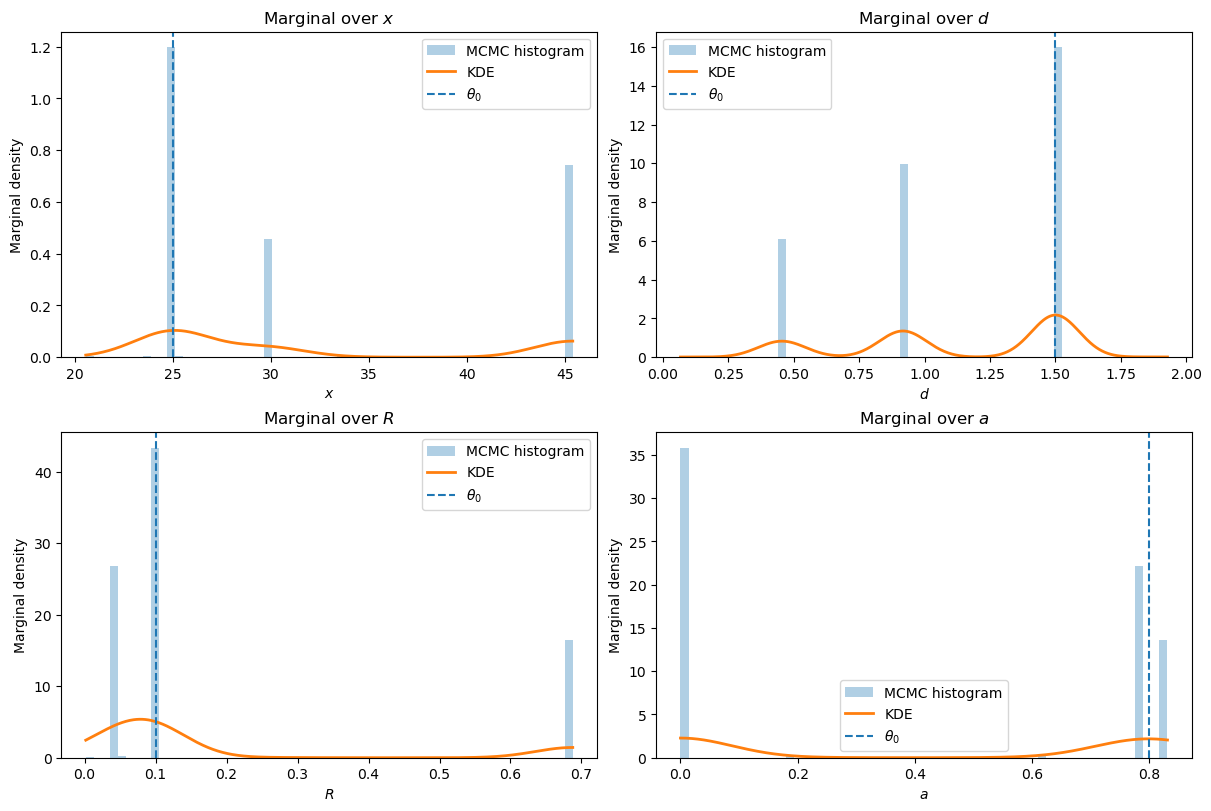

In [20]:
parameter_names = [
    r"$x$",
    r"$d$",
    r"$R$",
    r"$a$",
]

representative_values = np.array([
    X0,
    D0,
    R0,
    A0,
])

figure, axes = plt.subplots(
    2,
    2,
    figsize=(12, 8),
    constrained_layout=True,
)

for parameter_index, axis in enumerate(axes.flat):

    values = marginal_samples[:, parameter_index]

    # Histogram estimate.
    axis.hist(
        values,
        bins=60,
        density=True,
        alpha=0.35,
        label="MCMC histogram",
    )

    # KDE estimate.
    kde = gaussian_kde(values)

    grid = np.linspace(
        values.min(),
        values.max(),
        500,
    )

    axis.plot(
        grid,
        kde(grid),
        linewidth=2,
        label="KDE",
    )

    # Representative atom value.
    axis.axvline(
        representative_values[parameter_index],
        linestyle="--",
        linewidth=1.5,
        label=r"$\theta_0$",
    )

    axis.set_xlabel(
        parameter_names[parameter_index]
    )
    
    axis.set_ylabel("Marginal density")
    
    axis.set_title(
        f"Marginal over {parameter_names[parameter_index]}"
    )

    axis.legend()

plt.show()

### Check exchangeability explicitly

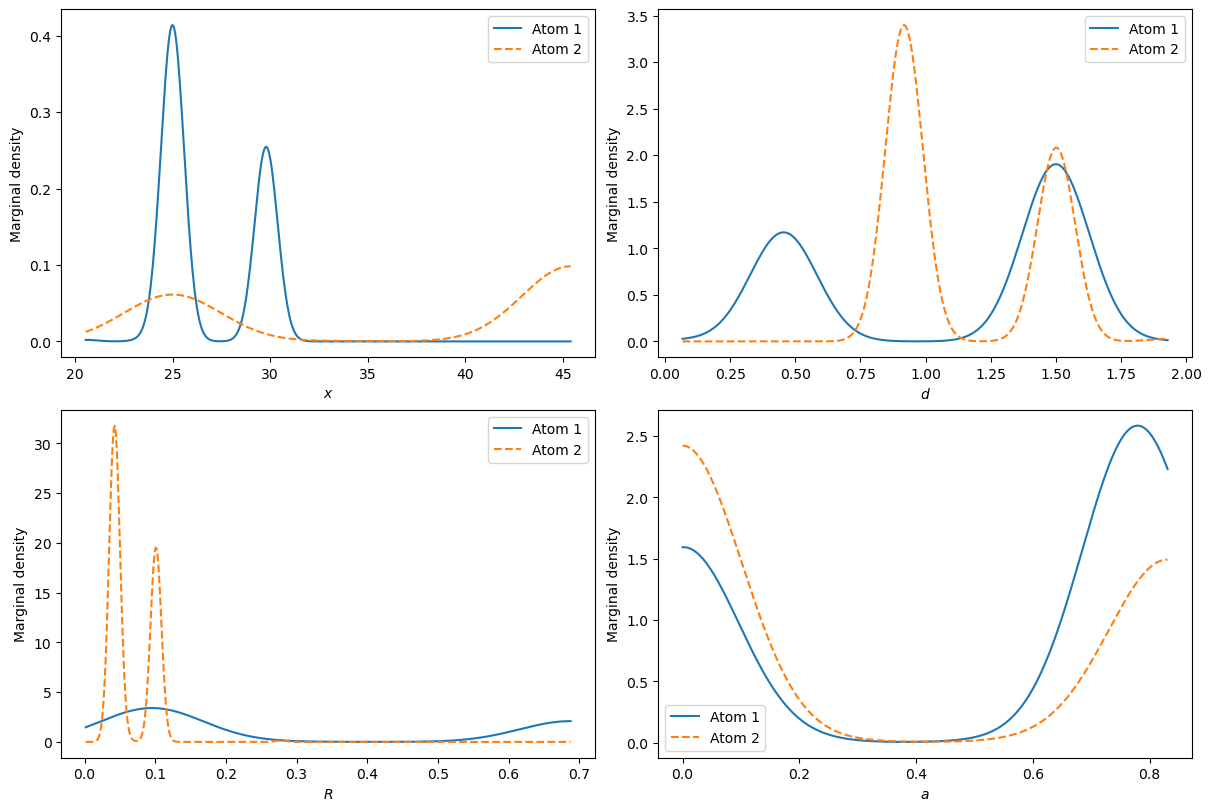

In [21]:
figure, axes = plt.subplots(
    2,
    2,
    figsize=(12, 8),
    constrained_layout=True,
)

for parameter_index, axis in enumerate(axes.flat):

    values_1 = atom_1_samples[:, parameter_index]
    values_2 = atom_2_samples[:, parameter_index]

    grid_min = min(
        values_1.min(),
        values_2.min(),
    )
    
    grid_max = max(
        values_1.max(),
        values_2.max(),
    )

    grid = np.linspace(
        grid_min,
        grid_max,
        500,
    )

    kde_1 = gaussian_kde(values_1)
    kde_2 = gaussian_kde(values_2)

    axis.plot(
        grid,
        kde_1(grid),
        label="Atom 1",
    )

    axis.plot(
        grid,
        kde_2(grid),
        linestyle="--",
        label="Atom 2",
    )

    axis.set_xlabel(
        parameter_names[parameter_index]
    )
    
    axis.set_ylabel("Marginal density")
    
    axis.legend()

plt.show()